
# Content-Based Visualization Notebook (TF-IDF vs BoW)

This notebook explicitly shows:
1. Input BEFORE TF-IDF & BoW
2. TF-IDF Matrix (IMPORTANT)
3. BoW Matrix
4. Final Comparison Visualization


In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

from pathlib import Path
PROJECT_ROOT = Path('..').resolve()
DATA_PROCESSED = PROJECT_ROOT / 'data' / 'processed'
courses = pd.read_csv(DATA_PROCESSED / 'cleaned_courses.csv')



courses.head()


,COURSE_ID,TITLE,Database,Python,CloudComputing,DataAnalysis,Containers,MachineLearning,ComputerVision,DataScience,BigData,Chatbot,R,BackendDev,FrontendDev,Blockchain,num_genres,clean_text
0,ML0201EN,robots are coming build iot apps with watson ...,0,0,0,0,0,0,0,0,0,0,0,1,1,0,2,BackendDev FrontendDev
1,ML0122EN,accelerating deep learning with gpu,0,1,0,0,0,1,0,1,0,0,0,0,0,0,3,Python MachineLearning DataScience
2,GPXX0ZG0EN,consuming restful services using the reactive ...,0,0,0,0,0,0,0,0,0,0,0,1,1,0,2,BackendDev FrontendDev
3,RP0105EN,analyzing big data in r using apache spark,1,0,0,1,0,0,0,0,1,0,1,0,0,0,4,Database DataAnalysis BigData R
4,GPXX0Z2PEN,containerizing packaging and running a sprin...,0,0,0,0,1,0,0,0,0,0,0,1,0,0,2,Containers BackendDev


##  Step 1: Prepare Text Input (What goes INTO models)

In [2]:

# Combine features into one text column (example)
text_features = courses.fillna('').astype(str).agg(' '.join, axis=1)

print("🔥 Sample INPUT to models (first 5 rows):\n")
for i in range(5):
    print(f"Course {i}:")
    print(text_features.iloc[i][:300])
    print("-"*50)


🔥 Sample INPUT to models (first 5 rows):

Course 0:
ML0201EN robots are coming  build iot apps with watson  swift  and node red 0 0 0 0 0 0 0 0 0 0 0 1 1 0 2 BackendDev FrontendDev
--------------------------------------------------
Course 1:
ML0122EN accelerating deep learning with gpu 0 1 0 0 0 1 0 1 0 0 0 0 0 0 3 Python MachineLearning DataScience
--------------------------------------------------
Course 2:
GPXX0ZG0EN consuming restful services using the reactive jax rs client 0 0 0 0 0 0 0 0 0 0 0 1 1 0 2 BackendDev FrontendDev
--------------------------------------------------
Course 3:
RP0105EN analyzing big data in r using apache spark 1 0 0 1 0 0 0 0 1 0 1 0 0 0 4 Database DataAnalysis BigData R
--------------------------------------------------
Course 4:
GPXX0Z2PEN containerizing  packaging  and running a spring boot application 0 0 0 0 1 0 0 0 0 0 0 1 0 0 2 Containers BackendDev
--------------------------------------------------


## Step 2: TF-IDF Representation (VERY IMPORTANT)

In [3]:

tfidf = TfidfVectorizer(max_features=100)
tfidf_matrix = tfidf.fit_transform(text_features)

tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=tfidf.get_feature_names_out())

print("TF-IDF Matrix Shape:", tfidf_df.shape)
tfidf_df.head()


TF-IDF Matrix Shape: (307, 100)


,101,advanced,ai,an,analysis,analytics,and,apache,application,applications,...,text,the,to,using,vision,visualization,watson,web,with,your
0,0.0,0.0,0.0,0.0,0.0,0.0,0.272935,0.000000,0.000000,0.0,...,0.0,0.000000,0.0,0.000000,0.0,0.0,0.479576,0.0,0.234130,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,...,0.0,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.0,0.300135,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,...,0.0,0.347961,0.0,0.260985,0.0,0.0,0.000000,0.0,0.000000,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.472279,0.000000,0.0,...,0.0,0.000000,0.0,0.284299,0.0,0.0,0.000000,0.0,0.000000,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.387552,0.000000,0.661964,0.0,...,0.0,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.0


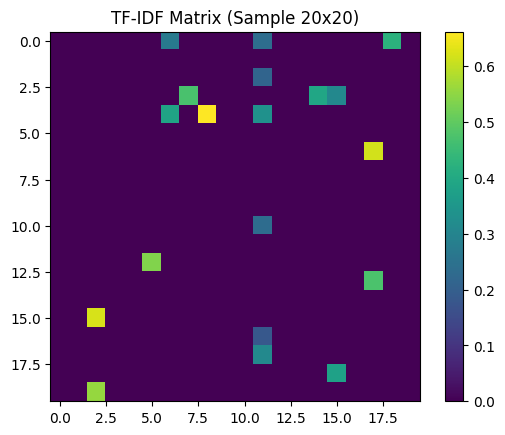

In [4]:

# Visualize TF-IDF
plt.figure()
plt.imshow(tfidf_df.iloc[:20, :20])
plt.title("TF-IDF Matrix (Sample 20x20)")
plt.colorbar()
plt.show()


##  Step 3: Bag of Words (BoW) Representation

In [5]:

bow = CountVectorizer(max_features=100)
bow_matrix = bow.fit_transform(text_features)

bow_df = pd.DataFrame(bow_matrix.toarray(), columns=bow.get_feature_names_out())

print("BoW Matrix Shape:", bow_df.shape)
bow_df.head()


BoW Matrix Shape: (307, 100)


,101,advanced,ai,an,analysis,analytics,and,apache,application,applications,...,text,the,to,using,vision,visualization,watson,web,with,your
0,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,1,0,1,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
2,0,0,0,0,0,0,0,0,0,0,...,0,1,0,1,0,0,0,0,0,0
3,0,0,0,0,0,0,0,1,0,0,...,0,0,0,1,0,0,0,0,0,0
4,0,0,0,0,0,0,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0


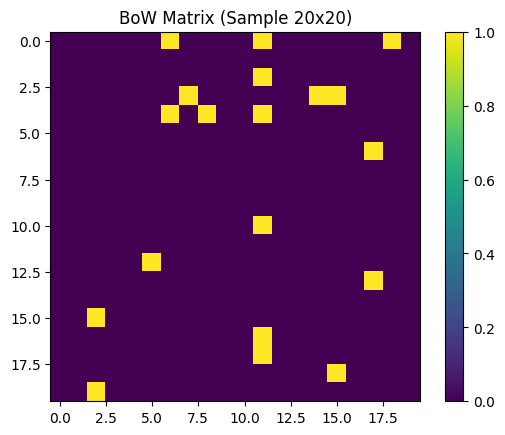

In [6]:

# Visualize BoW
plt.figure()
plt.imshow(bow_df.iloc[:20, :20])
plt.title("BoW Matrix (Sample 20x20)")
plt.colorbar()
plt.show()


##  FINAL: TF-IDF vs BoW Comparison

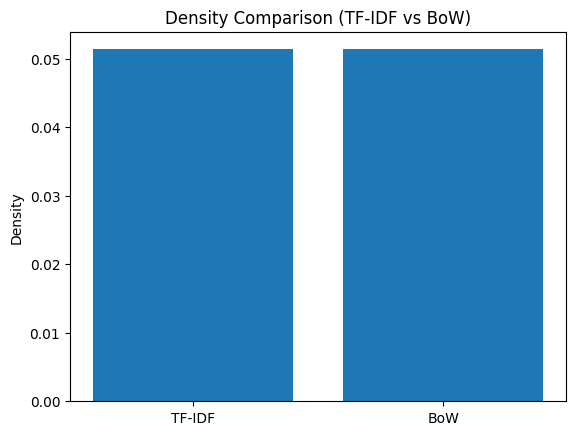

TF-IDF Density: 0.05136807817589577
BoW Density: 0.05136807817589577


In [7]:

tfidf_density = np.count_nonzero(tfidf_df.values) / tfidf_df.size
bow_density = np.count_nonzero(bow_df.values) / bow_df.size

labels = ["TF-IDF", "BoW"]
values = [tfidf_density, bow_density]

plt.figure()
plt.bar(labels, values)
plt.title("Density Comparison (TF-IDF vs BoW)")
plt.ylabel("Density")
plt.show()

print("TF-IDF Density:", tfidf_density)
print("BoW Density:", bow_density)
